## Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except:
    ! pip install seaborn
    import seaborn as sns
try:
    import pyarrow
except:
    ! pip install pyarrow
    import pyarrow

## Constants

In [2]:
str_dirname_output = './output'
str_svd_tuning = '../03_svd/output/df_tuning.csv'
str_svd_preds = '../03_svd/output/test_predictions.parquet'
str_ncf_tuning = '../04_neural_collaborative_filtering/output/df_tuning.csv'
str_ncf_preds = '../04_neural_collaborative_filtering/output/test_predictions.parquet'

## Output Directory

In [3]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

## Load SVD Results

In [4]:
df_svd = pd.read_csv(str_svd_tuning)
df_svd_preds = pd.read_parquet(str_svd_preds)
print(f'SVD tuning results loaded: {df_svd.shape}')
print(f'SVD test predictions loaded: {df_svd_preds.shape[0]:,} rows')

SVD tuning results loaded: (1, 20)
SVD test predictions loaded: 250,053 rows


## Load NCF Results

In [5]:
df_ncf = pd.read_csv(str_ncf_tuning)
df_ncf_preds = pd.read_parquet(str_ncf_preds)
print(f'NCF tuning results loaded: {df_ncf.shape}')
print(f'NCF test predictions loaded: {df_ncf_preds.shape[0]:,} rows')

NCF tuning results loaded: (1, 24)
NCF test predictions loaded: 250,053 rows


## Head-to-Head Comparison

In [6]:
# rating metrics comparison
list_rating_metrics = [
    'flt_rmse_train', 'flt_rmse_valid', 'flt_rmse_test',
    'flt_mae_train', 'flt_mae_valid', 'flt_mae_test',
]

# ranking metrics comparison
list_ranking_metrics = [
    col for col in df_svd.columns
    if col.startswith('flt_precision') or col.startswith('flt_recall')
    or col.startswith('flt_ndcg') or col.startswith('flt_map')
    or col.startswith('flt_hit_rate') or col.startswith('flt_coverage')
]

list_all_metrics = list_rating_metrics + list_ranking_metrics

list_dict_row = []
for str_metric in list_all_metrics:
    if str_metric in df_svd.columns and str_metric in df_ncf.columns:
        flt_svd = df_svd[str_metric].iloc[0]
        flt_ncf = df_ncf[str_metric].iloc[0]
        dict_row = {
            'metric': str_metric,
            'svd': flt_svd,
            'ncf': flt_ncf,
            'diff': flt_ncf - flt_svd,
            'pct_diff': (flt_ncf - flt_svd) / abs(flt_svd) if flt_svd != 0 else 0.0,
        }
        list_dict_row.append(dict_row)

df_comparison = pd.DataFrame(list_dict_row)
print(df_comparison.to_string(index=False))

                   metric      svd      ncf      diff   pct_diff
           flt_rmse_train 0.861919 0.422129 -0.439791  -0.510246
           flt_rmse_valid 0.989065 1.045158  0.056093   0.056713
            flt_rmse_test 0.976057 1.027498  0.051442   0.052703
            flt_mae_train 0.673150 0.316381 -0.356769  -0.529999
            flt_mae_valid 0.788414 0.868538  0.080124   0.101627
             flt_mae_test 0.772859 0.842629  0.069771   0.090276
flt_precision_at_10_valid 0.001020 0.204900  0.203880 199.802000
   flt_recall_at_10_valid 0.000316 0.036517  0.036200 114.446205
     flt_ndcg_at_10_valid 0.010204 0.446586  0.436382  42.765417
      flt_map_at_10_valid 0.001020 0.116304  0.115284 112.977967
 flt_hit_rate_at_10_valid 0.010204 0.723000  0.712796  69.854000
       flt_coverage_valid 0.009575 0.153805  0.144230  15.063538
 flt_precision_at_10_test 0.002627 0.169200  0.166573  63.408800
    flt_recall_at_10_test 0.000751 0.033698  0.032947  43.847423
      flt_ndcg_at_10_test

## Metrics Comparison: Grouped Bar Chart

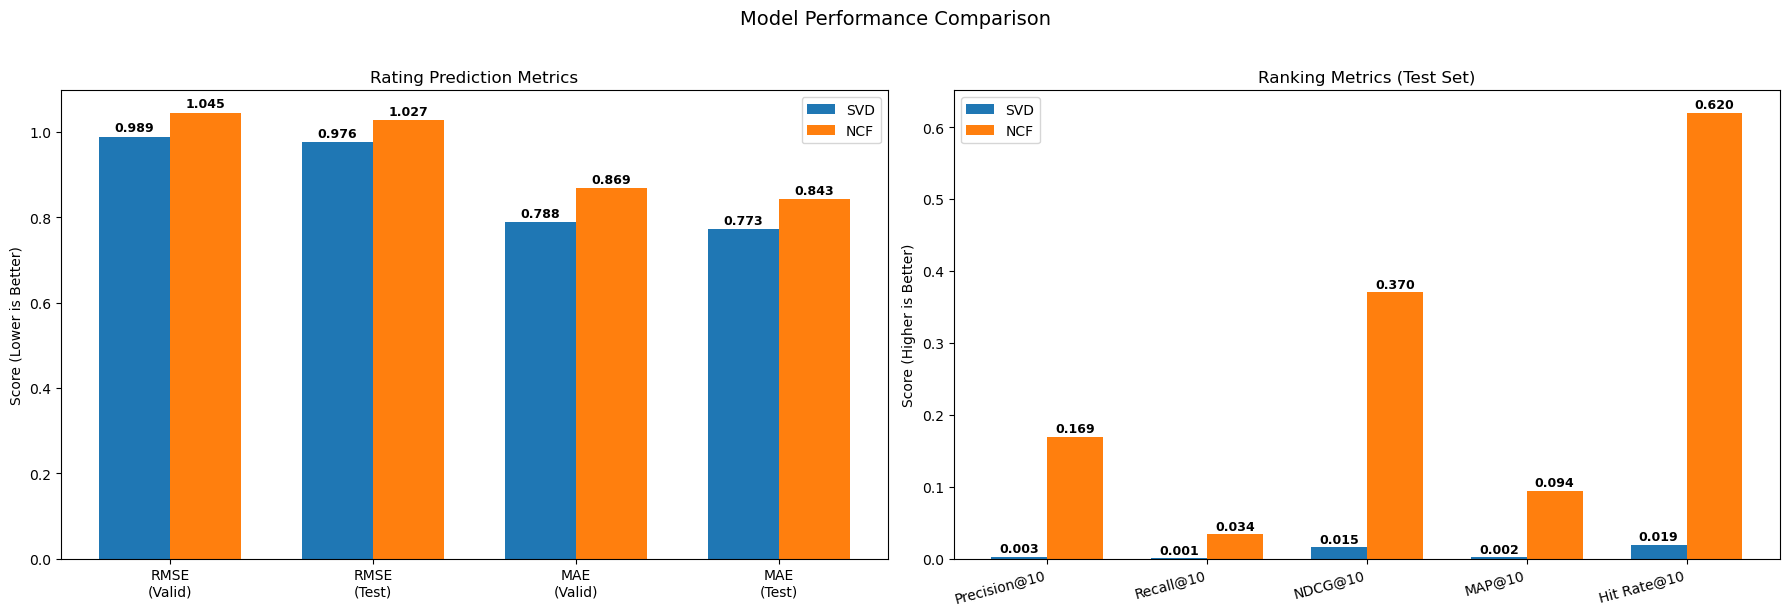

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Model Performance Comparison', fontsize=14, y=1.02)

# rating metrics (lower is better)
list_labels_rating = ['RMSE\n(Valid)', 'RMSE\n(Test)', 'MAE\n(Valid)', 'MAE\n(Test)']
list_svd_rating = [
    df_svd['flt_rmse_valid'].iloc[0], df_svd['flt_rmse_test'].iloc[0],
    df_svd['flt_mae_valid'].iloc[0], df_svd['flt_mae_test'].iloc[0],
]
list_ncf_rating = [
    df_ncf['flt_rmse_valid'].iloc[0], df_ncf['flt_rmse_test'].iloc[0],
    df_ncf['flt_mae_valid'].iloc[0], df_ncf['flt_mae_test'].iloc[0],
]

x = np.arange(len(list_labels_rating))
flt_width = 0.35

bars1 = axes[0].bar(x - flt_width / 2, list_svd_rating, flt_width, label='SVD', color='tab:blue')
bars2 = axes[0].bar(x + flt_width / 2, list_ncf_rating, flt_width, label='NCF', color='tab:orange')

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[0].set_ylabel('Score (Lower is Better)')
axes[0].set_title('Rating Prediction Metrics')
axes[0].set_xticks(x)
axes[0].set_xticklabels(list_labels_rating)
axes[0].legend()

# ranking metrics (higher is better) - test set only
list_labels_ranking = ['Precision@10', 'Recall@10', 'NDCG@10', 'MAP@10', 'Hit Rate@10']
list_ranking_cols_test = [
    'flt_precision_at_10_test', 'flt_recall_at_10_test',
    'flt_ndcg_at_10_test', 'flt_map_at_10_test', 'flt_hit_rate_at_10_test',
]

list_svd_ranking = [df_svd[col].iloc[0] if col in df_svd.columns else 0.0 for col in list_ranking_cols_test]
list_ncf_ranking = [df_ncf[col].iloc[0] if col in df_ncf.columns else 0.0 for col in list_ranking_cols_test]

x2 = np.arange(len(list_labels_ranking))

bars3 = axes[1].bar(x2 - flt_width / 2, list_svd_ranking, flt_width, label='SVD', color='tab:blue')
bars4 = axes[1].bar(x2 + flt_width / 2, list_ncf_ranking, flt_width, label='NCF', color='tab:orange')

for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars4:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1].set_ylabel('Score (Higher is Better)')
axes[1].set_title('Ranking Metrics (Test Set)')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(list_labels_ranking, rotation=15, ha='right')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{str_dirname_output}/metrics_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

## Prediction Distribution Overlay

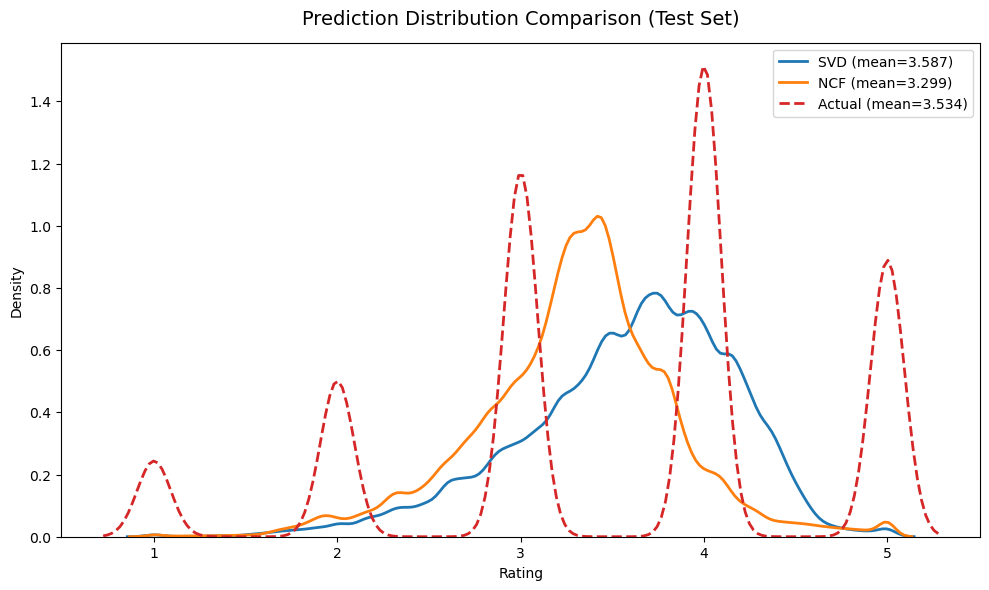

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.kdeplot(df_svd_preds['y_hat'], ax=ax, label=f'SVD (mean={df_svd_preds["y_hat"].mean():.3f})',
            color='tab:blue', linewidth=2)
sns.kdeplot(df_ncf_preds['y_hat'], ax=ax, label=f'NCF (mean={df_ncf_preds["y_hat"].mean():.3f})',
            color='tab:orange', linewidth=2)
sns.kdeplot(df_svd_preds['rating'], ax=ax, label=f'Actual (mean={df_svd_preds["rating"].mean():.3f})',
            color='tab:red', linestyle='--', linewidth=2)

ax.set_xlabel('Rating')
ax.set_ylabel('Density')
ax.set_title('Prediction Distribution Comparison (Test Set)', fontsize=14, y=1.02)
ax.legend()
plt.tight_layout()
plt.savefig(f'{str_dirname_output}/prediction_overlay.png', bbox_inches='tight', dpi=150)
plt.show()

## Error Distribution Comparison

/tmp/ipykernel_9574/1419816708.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_errors_melted, x='Model', y='Error', ax=axes[1],


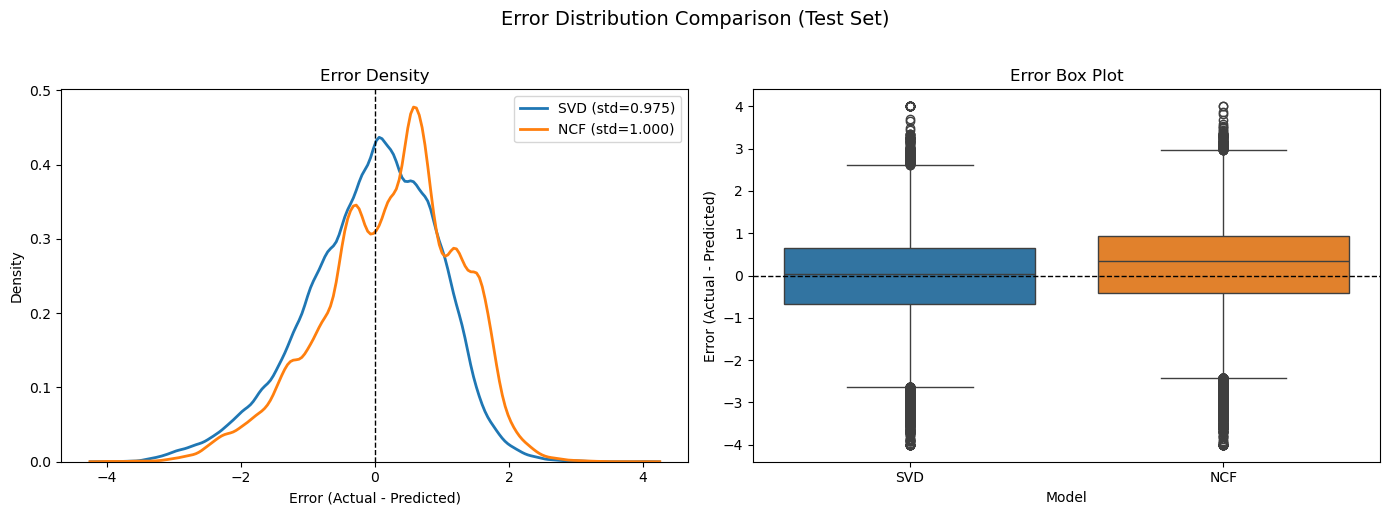

In [9]:
arr_svd_error = df_svd_preds['rating'].values - df_svd_preds['y_hat'].values
arr_ncf_error = df_ncf_preds['rating'].values - df_ncf_preds['y_hat'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Error Distribution Comparison (Test Set)', fontsize=14, y=1.02)

# overlaid KDE
sns.kdeplot(arr_svd_error, ax=axes[0], label=f'SVD (std={arr_svd_error.std():.3f})',
            color='tab:blue', linewidth=2)
sns.kdeplot(arr_ncf_error, ax=axes[0], label=f'NCF (std={arr_ncf_error.std():.3f})',
            color='tab:orange', linewidth=2)
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Error (Actual - Predicted)')
axes[0].set_ylabel('Density')
axes[0].set_title('Error Density')
axes[0].legend()

# box plot
df_errors = pd.DataFrame({
    'SVD': arr_svd_error,
    'NCF': arr_ncf_error,
})
df_errors_melted = df_errors.melt(var_name='Model', value_name='Error')
sns.boxplot(data=df_errors_melted, x='Model', y='Error', ax=axes[1],
            palette=['tab:blue', 'tab:orange'])
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Error Box Plot')
axes[1].set_ylabel('Error (Actual - Predicted)')

plt.tight_layout()
plt.savefig(f'{str_dirname_output}/error_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

## Conclusion

In [10]:
# determine champion model based on test RMSE
flt_svd_rmse = df_svd['flt_rmse_test'].iloc[0]
flt_ncf_rmse = df_ncf['flt_rmse_test'].iloc[0]

str_champion = 'SVD' if flt_svd_rmse < flt_ncf_rmse else 'NCF'
flt_improvement = abs(flt_svd_rmse - flt_ncf_rmse) / max(flt_svd_rmse, flt_ncf_rmse) * 100

print(f'Champion Model (by Test RMSE): {str_champion}')
print(f'  SVD Test RMSE: {flt_svd_rmse:.4f}')
print(f'  NCF Test RMSE: {flt_ncf_rmse:.4f}')
print(f'  Relative Improvement: {flt_improvement:.2f}%')
print()
print('Note: The champion model should be selected based on the specific use case.')
print('For rating prediction accuracy, RMSE/MAE are the primary metrics.')
print('For top-N recommendation quality, Precision@K, NDCG@K, and Hit Rate@K are more relevant.')

Champion Model (by Test RMSE): SVD
  SVD Test RMSE: 0.9761
  NCF Test RMSE: 1.0275
  Relative Improvement: 5.01%

Note: The champion model should be selected based on the specific use case.
For rating prediction accuracy, RMSE/MAE are the primary metrics.
For top-N recommendation quality, Precision@K, NDCG@K, and Hit Rate@K are more relevant.
